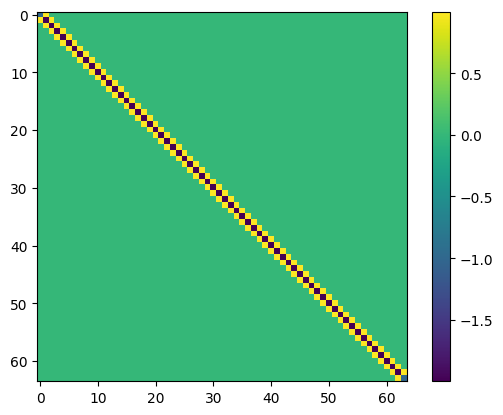

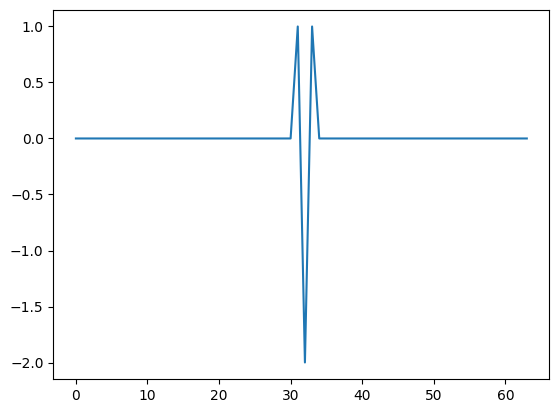

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 64
velocity_kernel = np.zeros((N - 1, N))
velocity_kernel[:, 1:] = np.eye(N - 1)
velocity_kernel -= np.eye(N - 1, N)
K = velocity_kernel.T @ velocity_kernel
sigma_B = 0.01

score_kernel = -np.linalg.inv(K + np.eye(N) / (sigma_B**2)) @ K / (sigma_B**2)
plt.imshow(score_kernel)
plt.colorbar()
plt.show()

plt.plot(score_kernel[N // 2])
plt.show()


## Approach 1 for computing obstacle-based energy landscape

Here, I try direct integration. However, I don't think this approach is very feasible.


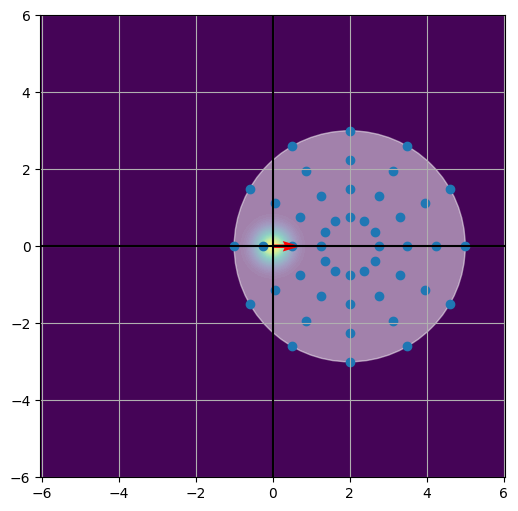

In [ ]:
import matplotlib.patches as patches

c_x = 2
R: float = 3

plt.figure(figsize=(6, 6))
plt.axis("equal")

# Color according to Gaussian.
gaussian_xx, gaussian_yy = np.meshgrid(
    np.linspace(-6, 6, 128),
    np.linspace(-6, 6, 128),
)
sigma_B = 0.3
gaussian_probability = (
    1
    / (2 * np.pi * sigma_B**2)
    * np.exp(-0.5 * (gaussian_xx**2 + gaussian_yy**2) / sigma_B**2)
)
plt.contourf(gaussian_xx, gaussian_yy, gaussian_probability, levels=50)
# plt.xlim(-6, 6)
plt.ylim(-6, 6)

plt.gca().axvline(x=0, color="k")
plt.gca().axhline(y=0, color="k")
plt.grid()
plt.gca().add_patch(patches.Circle((c_x, 0), R, fill=True, color="white", alpha=0.5))

N_segments = 12
angles = np.linspace(0, 2 * np.pi, N_segments, endpoint=False)
x = R * np.column_stack([np.cos(angles), np.sin(angles)])
evaluation_locations = np.concatenate([x, x * 0.75, x * 0.5, x * 0.25])
evaluation_locations[:, 0] += c_x
plt.scatter(evaluation_locations[:, 0], evaluation_locations[:, 1])

gaussian_evaluations = np.exp(
    -0.5
    * (evaluation_locations[:, 0] ** 2 + evaluation_locations[:, 1] ** 2)
    / sigma_B**2
)
gaussian_first_moment = (gaussian_evaluations[:, None] * evaluation_locations).sum(
    axis=0
)
denominator_B = gaussian_evaluations.sum()

displacement_direction = -1 / (2 * sigma_B**2) * gaussian_first_moment / denominator_B

plt.quiver(
    0, 0, displacement_direction[0], displacement_direction[1], color="red", scale=5
)

plt.show()

## Approach 2 for computing obstacle energy landscape

This approach is also numerical, but in terms of a much more precise integral.


In [ ]:
import time
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np


def compute_agent_obstacle_score(
    agent_x,
    agent_y,
    obs_x,
    obs_y,
    obs_rad,
    sigma,
    n_integral=10,
    numerator_magnitude_skip_cutoff=-1,
    denominator_computation_cutoff=2,
):
    """
    Allows computing the score (displacement direction) on an agent at (agent_x, agent_y)
    due to an obstacle at (obs_x, obs_y) with radius obs_rad. The score is computed using numerical integration with n_integral
    points.

    The numerator of the integral is known to be bounded above in magnitude, which limits the potential impact on the final result.
    If the upper bound is below numerator_magnitude_skip_cutoff, then the score is returned as zero.

    Additionally, if the denominator is below denominator_computation_cutoff, then a more accurate computation of the denominator is performed. However, given that the denominator is less than or equal to 1, and the integrand is positive, if e.g. the denominator
    is known to be very close to 1 already, then the more accurate computation is not necessary. The error in the denominator integral
    is bounded above by (1 - denominator).
    """

    d_a_o = np.sqrt((agent_x - obs_x) ** 2 + (agent_y - obs_y) ** 2)
    R = np.array(
        [
            [obs_x - agent_x, agent_y - obs_y],
            [obs_y - agent_y, obs_x - agent_x],
        ]
    )
    R = R / d_a_o

    # Compute numerator.
    r1 = min(abs(d_a_o - obs_rad), abs(d_a_o + obs_rad))
    r2 = max(abs(d_a_o - obs_rad), abs(d_a_o + obs_rad))
    r_values = np.linspace(r1, r2, n_integral, endpoint=False)
    dr = r_values[1] - r_values[0]
    r_values = r_values + dr / 2

    denominator_first_int = 1 - np.exp(-0.5 * (r1**2) / (sigma**2))
    denominator_third_int = -np.exp(-0.5 * (r2**2) / (sigma**2))

    if d_a_o < obs_rad:
        denominator_first_int = 0

    denominator = denominator_first_int + denominator_third_int
    numerator = 0.0
    numerator_magnitude_upper_bound = (
        2
        * (r2 - r1)
        * np.exp(-0.5 * (r1**2) / (sigma**2))
        * (r1**2)
        / (2 * np.pi * sigma**2)
    )
    if numerator_magnitude_upper_bound < numerator_magnitude_skip_cutoff:
        return np.array([0.0, 0.0])

    for r in r_values:
        intersection_eps_x = -(obs_rad**2 - r**2 - d_a_o**2) / (2 * d_a_o)

        if intersection_eps_x**2 > r**2:
            raise ValueError(f"Invalid intersection computation. {obs_rad} {r} {d_a_o}")

        intersection_eps_y = np.sqrt(r**2 - intersection_eps_x**2)
        numerator_integrand = (
            r
            * np.exp(-0.5 * (r**2) / (sigma**2))
            * intersection_eps_y
            / (2 * np.pi * sigma**2)
        )
        numerator += numerator_integrand * dr

        Theta = np.arccos(intersection_eps_x / r)

        if denominator < denominator_computation_cutoff:
            denominator += (
                2
                * r
                * (np.exp(-0.5 * (r**2) / (sigma**2)) / (2 * np.pi * sigma**2))
                * dr
                * Theta
            )

    numerator = R[:, 0] * numerator
    score = -1 / (sigma**2) * numerator / denominator

    return score


def compute_agent_obstacle_score_vectorized_integral(
    agent_x, agent_y, obs_x, obs_y, obs_rad, sigma, n_integral=10
):
    d_a_o = np.sqrt((agent_x - obs_x) ** 2 + (agent_y - obs_y) ** 2)
    R = np.array(
        [
            [obs_x - agent_x, agent_y - obs_y],
            [obs_y - agent_y, obs_x - agent_x],
        ]
    )
    R = R / d_a_o

    # Compute numerator.
    r1 = min(abs(d_a_o - obs_rad), abs(d_a_o + obs_rad))
    r2 = max(abs(d_a_o - obs_rad), abs(d_a_o + obs_rad))
    r_values = np.linspace(r1, r2, n_integral, endpoint=False)
    dr = r_values[1] - r_values[0]
    r_values = r_values + dr / 2

    denominator_first_int = 1 - np.exp(-0.5 * (r1**2) / (sigma**2))
    denominator_third_int = -np.exp(-0.5 * (r2**2) / (sigma**2))

    if d_a_o < obs_rad:
        denominator_first_int = 0

    denominator = denominator_first_int + denominator_third_int
    numerator = 0.0

    intersection_eps_x = -(obs_rad**2 - r_values**2 - d_a_o**2) / (2 * d_a_o)
    intersection_eps_y = np.sqrt(r_values**2 - intersection_eps_x**2)
    numerator_integrand = (
        r_values * np.exp(-0.5 * (r_values**2) / (sigma**2)) * intersection_eps_y
    )
    numerator += numerator_integrand.sum() * (dr / (2 * np.pi * sigma**2))

    Theta = np.arccos(intersection_eps_x / r_values)

    denominator += (
        r_values
        * (np.exp(-0.5 * (r_values**2) / (sigma**2)) / (2 * np.pi * sigma**2))
        * Theta
    ).sum() * (2 * dr)

    numerator = R[:, 0] * numerator
    score = -1 / (sigma**2) * numerator / denominator

    return score


def compute_agent_obstacle_distance_batched(
    agent_x_B: np.ndarray,
    agent_y_B: np.ndarray,
    obs_x_B: np.ndarray,
    obs_y_B: np.ndarray,
):
    d_a_o_B = np.sqrt((agent_x_B - obs_x_B) ** 2 + (agent_y_B - obs_y_B) ** 2)
    return d_a_o_B


def compute_r1_r2_batched(obs_rad_B: np.ndarray, d_a_o_B: np.ndarray):
    temp0 = np.abs(d_a_o_B - obs_rad_B)
    temp1 = np.abs(d_a_o_B + obs_rad_B)
    r1_B = np.minimum(temp0, temp1)
    r2_B = np.maximum(temp0, temp1)
    return (r1_B, r2_B)


def compute_agent_obstacle_score_batched(
    agent_x_B: np.ndarray,
    agent_y_B: np.ndarray,
    obs_x_B: np.ndarray,
    obs_y_B: np.ndarray,
    obs_rad_B: np.ndarray,
    sigma_B: np.ndarray,
    r1_B: np.ndarray,
    r2_B: np.ndarray,
    d_a_o_B: np.ndarray,
    n_integral=10,
):
    """
    Here, 'B' indicates the batch dimension, 'D' indicates the spatial dimension, and 'T' indicates
    the *integral* dimension, not time.

    Values that may be precomputed to truncate the computation space (r1_B, r2_B, d_a_o_B) are passed in
    so that they do not need to be recomputed.
    """

    # Batch on last dimension to make broadcasting easier.
    r_values_T_B = (
        np.linspace(0, 1, n_integral, endpoint=False)[:, None] * (r2_B - r1_B)[None, :]
        + r1_B[None, :]
    )
    dr_B = r_values_T_B[1, :] - r_values_T_B[0, :]
    r_values_T_B = r_values_T_B + dr_B / 2

    denominator_first_int_B = 1 - np.exp(-0.5 * (r1_B**2) / (sigma_B**2))
    denominator_third_int_B = -np.exp(-0.5 * (r2_B**2) / (sigma_B**2))
    denominator_first_int_B[d_a_o_B < obs_rad_B] = 0

    denominator_B = denominator_first_int_B + denominator_third_int_B
    numerator_B = np.zeros_like(denominator_B)

    intersection_eps_x_T_B = -(obs_rad_B**2 - r_values_T_B**2 - d_a_o_B**2) / (
        2 * d_a_o_B
    )
    intersection_eps_y_T_B = np.sqrt(r_values_T_B**2 - intersection_eps_x_T_B**2)
    numerator_integrand_T_B = (
        r_values_T_B
        * np.exp(-0.5 * (r_values_T_B**2) / (sigma_B**2))
        * intersection_eps_y_T_B
    )
    numerator_B += numerator_integrand_T_B.sum(axis=0) * (
        dr_B / (2 * np.pi * sigma_B**2)
    )

    Theta_T_B = np.arccos(intersection_eps_x_T_B / r_values_T_B)

    denominator_B += (
        r_values_T_B
        * (np.exp(-0.5 * (r_values_T_B**2) / (sigma_B**2)) / (2 * np.pi * sigma_B**2))
        * Theta_T_B
    ).sum(axis=0) * (2 * dr_B)

    # Avoid creating R array.
    numerator_D_B = (
        np.stack([obs_x_B - agent_x_B, agent_y_B - obs_y_B], axis=0)
        / d_a_o_B
        * numerator_B[None, :]
    )
    score_D_B = -1 / (sigma_B**2) * numerator_D_B / denominator_B

    return score_D_B.T

In [252]:
# Verify that the batched version matches the unbatched version.
displacement_directions_unbatched = {}
displacement_directions_single_batched = {}
displacement_directions_batched = {}

for c_x in [2, 4, 6]:
    for R in [1, 3, 5]:
        for sigma in [0.1, 0.3, 0.5]:
            t0 = time.time()
            result = compute_agent_obstacle_score(
                0,
                0,
                c_x,
                0,
                R,
                sigma,
                n_integral=200,
            )
            t1 = time.time()
            displacement_directions_unbatched[c_x, R, sigma] = (result, t1 - t0)

            t0 = time.time()
            agent_x_B = np.array([0])
            agent_y_B = np.array([0])
            obs_x_B = np.array([c_x])
            obs_y_B = np.array([0])
            obs_rad_B = np.array([R])
            sigma_B = np.array([sigma])
            d_a_o_B = compute_agent_obstacle_distance_batched(
                agent_x_B, agent_y_B, obs_x_B, obs_y_B
            )
            r1_B, r2_B = compute_r1_r2_batched(obs_rad_B, d_a_o_B)
            result = compute_agent_obstacle_score_batched(
                agent_x_B,
                agent_y_B,
                obs_x_B,
                obs_y_B,
                obs_rad_B,
                sigma_B,
                r1_B,
                r2_B,
                d_a_o_B,
                n_integral=200,
            )
            t1 = time.time()
            displacement_directions_single_batched[c_x, R, sigma] = (result, t1 - t0)

            result1 = displacement_directions_unbatched[c_x, R, sigma][0]
            result2 = displacement_directions_single_batched[c_x, R, sigma][0][0]

            assert np.allclose(result1, result2, atol=1e-6), (
                f"Mismatch for {c_x}, {R}, {sigma}"
            )

t0 = time.time()
keys = list(displacement_directions_unbatched.keys())
agent_x_B = np.zeros(len(keys))
agent_y_B = np.zeros(len(keys))
obs_x_B = np.array([k[0] for k in keys])
obs_y_B = np.zeros(len(keys))
obs_rad_B = np.array([k[1] for k in keys])
sigma_B = np.array([k[2] for k in keys])
d_a_o_B = compute_agent_obstacle_distance_batched(
    agent_x_B, agent_y_B, obs_x_B, obs_y_B
)
r1_B, r2_B = compute_r1_r2_batched(obs_rad_B, d_a_o_B)
displacement_directions_batch = compute_agent_obstacle_score_batched(
    agent_x_B,
    agent_y_B,
    obs_x_B,
    obs_y_B,
    obs_rad_B,
    sigma_B,
    r1_B,
    r2_B,
    d_a_o_B,
    n_integral=200,
)
t1 = time.time()

duration = t1 - t0
average_duration_batched = duration / len(keys)
average_duration_unbatched = 0

for i, k in enumerate(keys):
    result1 = displacement_directions_unbatched[k][0]
    result2 = displacement_directions_batch[i]

    average_duration_unbatched += displacement_directions_unbatched[k][1]

    assert np.allclose(result1, result2, atol=1e-6), f"Mismatch for {k}"

average_duration_unbatched /= len(keys)

print("All tests passed.")
print(
    f"{average_duration_batched=} {average_duration_unbatched=} ratio={average_duration_unbatched / average_duration_batched:.2f}"
)


All tests passed.
average_duration_batched=0.00024281607733832466 average_duration_unbatched=0.0010559823777940539 ratio=4.35


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


5.602836608886719e-05
5 1 [-7.48231458e-40 -0.00000000e+00]
0.0003838539123535156
2.5 1 [-1.55274243e-06 -0.00000000e+00]
6.29425048828125e-05
0.5 1 [-1.23560901 -0.        ]
5.507469177246094e-05
5 3 [-1.18238275e-10 -0.00000000e+00]
5.2928924560546875e-05
2.5 3 [-0.9280294 -0.       ]
4.1961669921875e-05
0.5 3 [-1.81133721 -0.        ]
6.008148193359375e-05
5 5 [-1.35897749 -0.        ]
5.1021575927734375e-05
2.5 5 [-1.06160295 -0.        ]
5.030632019042969e-05
0.5 5 [-2.29125167 -0.        ]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


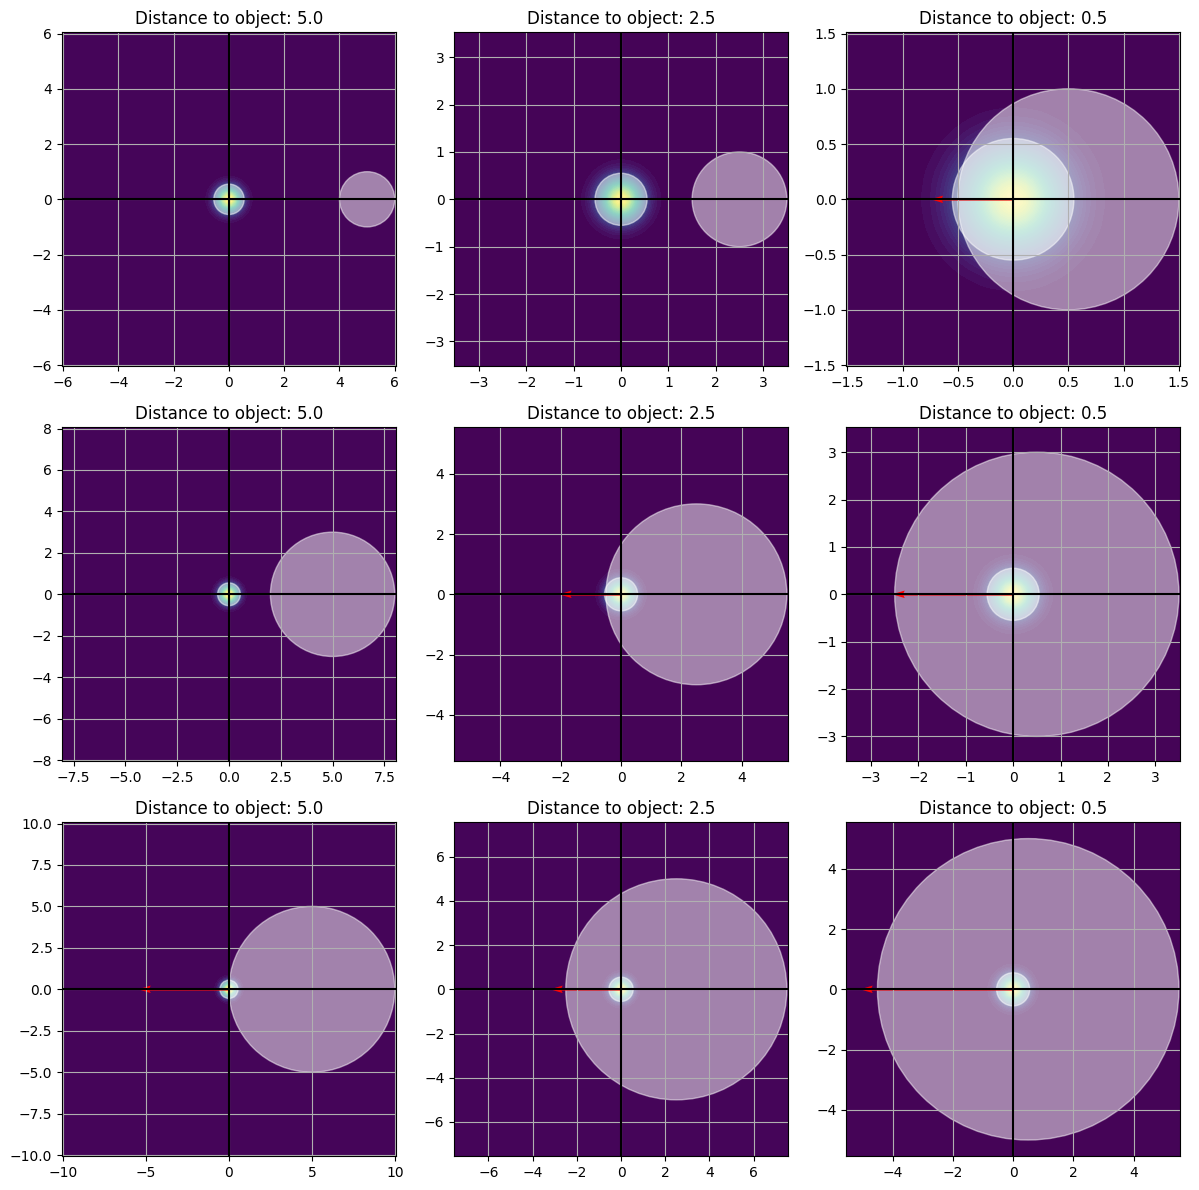

In [ ]:
plt.figure(figsize=(12, 12))

i = 1
for obs_rad_B in [1, 3, 5]:
    for c_x in [5, 2.5, 0.5]:
        plt.subplot(3, 3, i)
        i += 1

        plt.title(f"Distance to object: {c_x:.1f}")

        # if obs_rad != 1 or c_x != 0.5:
        #     continue

        R = obs_rad_B

        # Color according to Gaussian.
        square_size = c_x + R + 3
        gaussian_xx, gaussian_yy = np.meshgrid(
            np.linspace(-square_size, square_size, 128),
            np.linspace(-square_size, square_size, 128),
        )
        sigma_B = 0.3
        gaussian_probability = (
            1
            / (2 * np.pi * sigma_B**2)
            * np.exp(-0.5 * (gaussian_xx**2 + gaussian_yy**2) / sigma_B**2)
        )
        plt.contourf(gaussian_xx, gaussian_yy, gaussian_probability, levels=50)

        plt.gca().axvline(x=0, color="k")
        plt.gca().axhline(y=0, color="k")
        plt.grid()
        plt.gca().add_patch(
            patches.Circle((c_x, 0), R, fill=True, color="white", alpha=0.5)
        )
        plt.gca().add_patch(
            patches.Circle((0, 0), 0.55, fill=True, color="white", alpha=0.5)
        )

        t0 = time.time()
        displacement_direction = compute_agent_obstacle_score_vectorized_integral(
            0, 0, c_x, 0, R, sigma_B, n_integral=200
        )
        t1 = time.time()
        print(t1 - t0)
        print(c_x, R, displacement_direction)

        plt.quiver(
            0,
            0,
            displacement_direction[0],
            displacement_direction[1],
            color="red",
            scale=5,
        )
        plt.axis("equal")

        plt.xlim(-square_size + 3, square_size - 3)
        plt.ylim(-square_size + 3, square_size - 3)

plt.tight_layout()
plt.show()

/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_24676/2022902972.py:199: RuntimeWarning: invalid value encountered in divide
  intersection_eps_x_T_B = -(obs_rad_B**2 - r_values_T_B**2 - d_a_o_B**2) / (
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_24676/2022902972.py:220: RuntimeWarning: invalid value encountered in divide
  np.stack([obs_x_B - agent_x_B, agent_y_B - obs_y_B], axis=0)


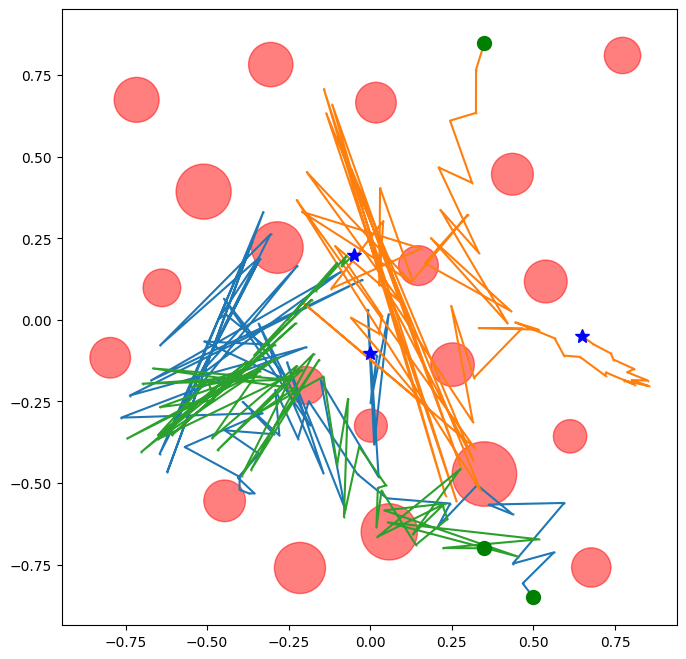

In [284]:
# Implementing Langevin dynamics!
from dataclasses import dataclass
import json

from matplotlib.axes import Axes
from functools import lru_cache
import numpy as np
import PIL.Image
import io
from pathlib import Path
import av


@dataclass
class Problem:
    num_timesteps: int
    agent_start_positions: np.ndarray
    agent_end_positions: np.ndarray
    agent_reference_trajectory: np.ndarray | None
    agent_radii: np.ndarray
    agent_max_speeds: np.ndarray
    obstacle_positions: np.ndarray
    obstacle_radii: np.ndarray

    @property
    def num_agents(self):
        return self.agent_start_positions.shape[0]

    @property
    def num_obstacles(self):
        return self.obstacle_positions.shape[0]

    def visualize(self, agent_positions: np.ndarray, ax: Axes):
        # Plot the obstacles
        for obs_index in range(self.num_obstacles):
            x, y = self.obstacle_positions[obs_index].tolist()
            ax.add_patch(
                patches.Circle(
                    (x, y), self.obstacle_radii[obs_index].item(), color="r", alpha=0.5
                )
            )

        # Plot the agents' trajectories
        for agent_index in range(self.num_agents):
            if agent_positions.shape[0] == 1:
                x, y = agent_positions[0, agent_index].tolist()
                ax.add_patch(
                    patches.Circle((x, y), self.agent_radii[agent_index].item())
                )
            else:
                ax.plot(
                    agent_positions[:, agent_index, 0],
                    agent_positions[:, agent_index, 1],
                    marker="o",
                    label=f"Agent {agent_index}",
                    # set size to agent radius
                    markersize=self.agent_radii[agent_index].item() * 10,
                )
        # Plot the agents' start and goal positions
        for agent_index in range(self.num_agents):
            (sx, sy) = self.agent_start_positions[agent_index]
            (ex, ey) = self.agent_end_positions[agent_index]
            ax.plot(
                sx,
                sy,
                marker="o",
                color="green",
                markersize=10,
                label=f"Start {agent_index}",
            )
            ax.plot(
                ex,
                ey,
                marker="*",
                color="blue",
                markersize=10,
                label=f"Goal {agent_index}",
            )

        ax.set_aspect("equal")

    @classmethod
    def from_json(cls, entry):
        return cls(
            num_timesteps=entry["num_timesteps"],
            agent_start_positions=np.array(entry["agents"]["start_positions"]),
            agent_end_positions=np.array(entry["agents"]["end_positions"]),
            agent_radii=np.array(entry["agents"]["radii"]),
            agent_max_speeds=np.array(entry["agents"]["max_speeds"]),
            agent_reference_trajectory=None,
            obstacle_positions=np.array(entry["obstacles"]["positions"]),
            obstacle_radii=np.array(entry["obstacles"]["radii"]),
        )


@lru_cache(maxsize=16)
def get_velocity_kernel(N: int, sigma: float):
    velocity_kernel = np.zeros((N - 1, N))
    velocity_kernel[:, 1:] = np.eye(N - 1)
    velocity_kernel -= np.eye(N - 1, N)
    VTV = velocity_kernel.T @ velocity_kernel
    score_kernel = -np.linalg.inv(VTV + np.eye(N) / (sigma**2)) @ VTV / (sigma**2)
    return score_kernel


def compute_kinetic_energy_score(trajectory: np.ndarray, sigma):
    return np.einsum(
        "it,tad->iad", get_velocity_kernel(trajectory.shape[0], sigma), trajectory
    )


def clip_magnitude(vector, max_magnitude):
    magnitude = np.linalg.norm(vector)
    if magnitude > max_magnitude:
        return vector / magnitude * max_magnitude
    else:
        return vector


def step_langevin(
    trajectory, sigma, step_size, problem: Problem, include_obstacles=True
):
    score = np.zeros_like(trajectory)

    if include_obstacles:
        for t in range(trajectory.shape[0]):
            for agent in range(trajectory.shape[1]):
                agent_x = trajectory[t, agent, 0]
                agent_y = trajectory[t, agent, 1]

                for obs_idx in range(obstacle_positions.shape[0]):
                    obs_x = obstacle_positions[obs_idx, 0]
                    obs_y = obstacle_positions[obs_idx, 1]
                    obs_rad = obstacle_radii[obs_idx]

                    score[t, agent] += clip_magnitude(
                        compute_agent_obstacle_score(
                            agent_x,
                            agent_y,
                            obs_x,
                            obs_y,
                            obs_rad + problem.agent_radii[agent],
                            sigma,
                        ),
                        1.0,
                    )

                for other_agent in range(trajectory.shape[1]):
                    if other_agent == agent:
                        continue
                    other_agent_x = trajectory[t, other_agent, 0]
                    other_agent_y = trajectory[t, other_agent, 1]

                    score[t, agent] += clip_magnitude(
                        compute_agent_obstacle_score(
                            agent_x,
                            agent_y,
                            other_agent_x,
                            other_agent_y,
                            problem.agent_radii[agent]
                            + problem.agent_radii[other_agent],
                            np.sqrt(2) * sigma,  # sum the variances
                        ),
                        1.0,
                    )

    score = score + 10 * compute_kinetic_energy_score(trajectory, sigma)

    return (
        trajectory + step_size * score
        # + np.sqrt(2 * step_size) * np.random.randn(*trajectory.shape)
    )


def step_langevin_batched(
    trajectory,
    sigma,
    step_size,
    problem: Problem,
    include_obstacles=True,
    n_integral=50,
    include_noise_term=False,
):
    """
    Batches across agents and obstacles.
    """

    score = np.zeros_like(trajectory)

    if include_obstacles:
        # Create batch for agent-obstacle interactions.
        agent_x_T_A = trajectory[:, :, 0]
        agent_y_T_A = trajectory[:, :, 1]
        obstacle_x_O = obstacle_positions[:, 0]
        obstacle_y_O = obstacle_positions[:, 1]
        obstacle_rad_O = obstacle_radii
        sigma_OA = sigma * np.ones(obstacle_radii.shape[0] * trajectory.shape[1])

        agent_x_T_A_O = np.repeat(
            agent_x_T_A[:, :, None], obstacle_positions.shape[0], axis=2
        )
        agent_y_T_A_O = np.repeat(
            agent_y_T_A[:, :, None], obstacle_positions.shape[0], axis=2
        )
        obstacle_x_T_A_O = np.repeat(
            obstacle_x_O[None, None, :], trajectory.shape[0], axis=0
        )
        obstacle_x_T_A_O = np.repeat(obstacle_x_T_A_O, trajectory.shape[1], axis=1)
        obstacle_y_T_A_O = np.repeat(
            obstacle_y_O[None, None, :], trajectory.shape[0], axis=0
        )
        obstacle_y_T_A_O = np.repeat(obstacle_y_T_A_O, trajectory.shape[1], axis=1)
        obstacle_rad_T_A_O = np.repeat(
            (problem.agent_radii[:, None] + obstacle_rad_O[None, :])[None, :, :],
            trajectory.shape[0],
            axis=0,
        )
        sigma_T_A_O = np.repeat(sigma_OA[None, :], trajectory.shape[0], axis=0)

        T, A, O = agent_x_T_A_O.shape

        agent_x_T_A1_A2 = np.repeat(
            agent_x_T_A[:, :, None], trajectory.shape[1], axis=2
        )
        agent_x_T_A2_A1 = np.repeat(
            agent_x_T_A[:, None, :], trajectory.shape[1], axis=1
        )
        agent_y_T_A1_A2 = np.repeat(
            agent_y_T_A[:, :, None], trajectory.shape[1], axis=2
        )
        agent_y_T_A2_A1 = np.repeat(
            agent_y_T_A[:, None, :], trajectory.shape[1], axis=1
        )
        sigma_T_A1_A2 = (
            np.sqrt(2)
            * sigma
            * np.ones((trajectory.shape[0], trajectory.shape[1], trajectory.shape[1]))
        )
        obstacle_rad_T_A1_A2 = np.repeat(
            (problem.agent_radii[:, None] + problem.agent_radii[None, :])[None, :, :],
            trajectory.shape[0],
            axis=0,
        )

        agent_x_flat = np.concatenate(
            [agent_x_T_A_O.reshape(-1), agent_x_T_A1_A2.reshape(-1)]
        )
        agent_y_flat = np.concatenate(
            [agent_y_T_A_O.reshape(-1), agent_y_T_A1_A2.reshape(-1)]
        )
        obstacle_x_flat = np.concatenate(
            [obstacle_x_T_A_O.reshape(-1), agent_x_T_A2_A1.reshape(-1)]
        )
        obstacle_y_flat = np.concatenate(
            [obstacle_y_T_A_O.reshape(-1), agent_y_T_A2_A1.reshape(-1)]
        )
        obstacle_rad_flat = np.concatenate(
            [obstacle_rad_T_A_O.reshape(-1), obstacle_rad_T_A1_A2.reshape(-1)]
        )
        sigma_flat = np.concatenate(
            [sigma_T_A_O.reshape(-1), sigma_T_A1_A2.reshape(-1)]
        )
        d_a_o_flat = compute_agent_obstacle_distance_batched(
            agent_x_flat, agent_y_flat, obstacle_x_flat, obstacle_y_flat
        )
        r1_flat, r2_flat = compute_r1_r2_batched(obstacle_rad_flat, d_a_o_flat)
        score_flat = compute_agent_obstacle_score_batched(
            agent_x_flat,
            agent_y_flat,
            obstacle_x_flat,
            obstacle_y_flat,
            obstacle_rad_flat,
            sigma_flat,
            r1_flat,
            r2_flat,
            d_a_o_flat,
            n_integral=n_integral,
        )

        # clip norm
        norm = np.linalg.norm(score_flat, axis=-1, keepdims=True)
        norm_clipped = np.clip(norm, 0, 1.0)
        score_flat = score_flat * (norm_clipped / (1e-8 + norm))

        # unpack scores.
        score_T_A_O_D = score_flat[: T * A * O, :].reshape(
            trajectory.shape[0], trajectory.shape[1], obstacle_positions.shape[0], 2
        )
        score_T_A1_A2_D = score_flat[T * A * O :, :].reshape(
            trajectory.shape[0], trajectory.shape[1], trajectory.shape[1], 2
        )
        score_T_A1_A2_D[np.isnan(score_T_A1_A2_D)] = 0.0
        # Don't compute self-interactions.
        score += (
            score_T_A1_A2_D.sum(axis=2)
            - np.diagonal(score_T_A1_A2_D, axis1=1, axis2=2).transpose(0, 2, 1)
        ) + (score_T_A_O_D.sum(axis=2))

    score = score + 10 * compute_kinetic_energy_score(trajectory, sigma)

    return (
        trajectory
        + step_size * score
        + (
            np.sqrt(2 * step_size) * np.random.randn(*trajectory.shape)
            if include_noise_term
            else 0
        )
    )


def save_video(problem: Problem, agent_positions: np.ndarray, path: str | Path):
    buf = io.BytesIO()
    images = []

    for step in range(problem.num_timesteps):
        plt.clf()
        problem.visualize(agent_positions[step : step + 1], plt.gca())
        plt.title(f"Timestep {step}")
        plt.savefig(buf, format="png")
        buf.seek(0)
        image = PIL.Image.open(buf).copy()
        images.append(image)
        buf.truncate(0)
        buf.seek(0)

    with av.open(path, "w") as container:
        stream = container.add_stream("h264", rate=4)
        for img in images:
            frame = av.VideoFrame.from_image(img)
            packet = stream.encode(frame)
            if packet:
                container.mux(packet)
        # Flush stream
        for packet in stream.encode(None):
            container.mux(packet)


with open("../instances_data/instances_dense.json") as f:
    instances = json.load(f)

instance = instances[0]
start_positions = np.array(instance["agents"]["start_positions"])
end_positions = np.array(instance["agents"]["end_positions"])
obstacle_positions = np.array(instance["obstacles"]["positions"])
obstacle_radii = np.array(instance["obstacles"]["radii"])

problem = Problem.from_json(instance)
trajectory = np.random.randn(64, len(instance["agents"]["start_positions"]), 2)
trajectory[0] = start_positions
trajectory[-1] = end_positions

schedule = [
    # (sigma, step_size, num_steps, include_obstacles)
    (1.0, 0.05, 400, False),
    (0.7, 0.05, 20, False),
    (0.3, 0.05, 20, True),
    (0.1, 0.05, 20, True),
    (0.01, 0.05, 20, True),
]

for sigma_B, step_size, num_steps, include_obstacles in schedule:
    for i in range(num_steps):
        trajectory = step_langevin_batched(
            trajectory,
            sigma=sigma_B,
            step_size=step_size,
            problem=problem,
            include_obstacles=include_obstacles,
            n_integral=200,
        )
        trajectory[0] = start_positions
        trajectory[-1] = end_positions

# Visualize the trajectory.
fig, ax = plt.subplots(figsize=(8, 8))
problem.visualize(trajectory, ax)
plt.show()


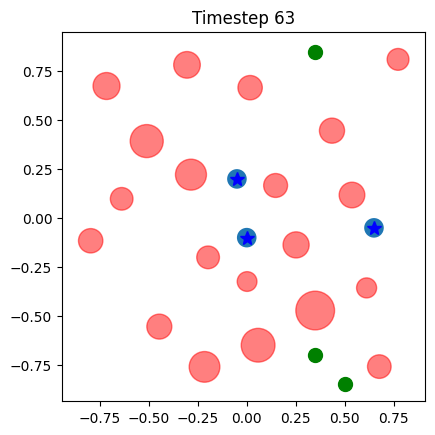

In [210]:
save_video(problem, trajectory, "trajectory_from_langevin.mp4")